In [1]:
# Standard library imports
import os
import random
import sys
from itertools import product

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('../src/')
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Project imports
from gaugefixer.features import get_pairwise_features
from gaugefixer.fixers import fix_pairwise_model
from gaugefixer.verify import verify_identical_evaluation, verify_marginalization
from gaugefixer.sequence import SeqEmbedder, get_alphabet, evaluate_model_on_seqs, randseqs 


In [2]:
# Plot parameters
def plot_pairwise_thetas(theta_series, fixed_theta_series):
    for order in range(3)[::-1]:
        ix = [len(orbit)==order for orbit,_ in theta_series.index]
        plt.scatter(theta_series[ix], fixed_theta_series[ix], marker='.', label=f'{order=}')
    plt.xlabel('theta_series')
    plt.ylabel('fixed_theta_series')
    plt.legend()
    print(f'features match: {all(theta_series.index == fixed_theta_series.index)}')

N=3,121
000 f=12.021758 	 f_fixed=12.021758, Passed
001 f=-8.553520 	 f_fixed=-8.553520, Passed
002 f=-17.509509 	 f_fixed=-17.509509, Passed
003 f=-18.200028 	 f_fixed=-18.200028, Passed
004 f=20.320186 	 f_fixed=20.320186, Passed
005 f=8.015730 	 f_fixed=8.015730, Passed
006 f=-19.649641 	 f_fixed=-19.649641, Passed
007 f=-4.755540 	 f_fixed=-4.755540, Passed
008 f=-2.558325 	 f_fixed=-2.558325, Passed
009 f=-29.450575 	 f_fixed=-29.450575, Passed
010 f=-6.061192 	 f_fixed=-6.061192, Passed
011 f=3.401010 	 f_fixed=3.401010, Passed
012 f=21.760797 	 f_fixed=21.760797, Passed
013 f=13.875986 	 f_fixed=13.875986, Passed
014 f=-0.138882 	 f_fixed=-0.138882, Passed
015 f=-16.461487 	 f_fixed=-16.461487, Passed
016 f=-20.430462 	 f_fixed=-20.430462, Passed
017 f=-17.989361 	 f_fixed=-17.989361, Passed
018 f=-2.750454 	 f_fixed=-2.750454, Passed
019 f=-2.555830 	 f_fixed=-2.555830, Passed
020 f=-1.403350 	 f_fixed=-1.403350, Passed
021 f=-14.679476 	 f_fixed=-14.679476, Passed
022 f=20.827

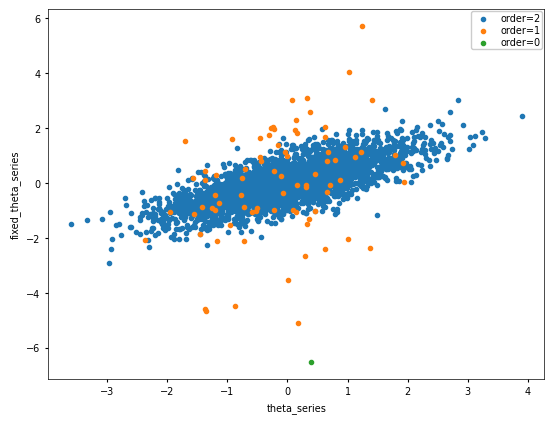

In [3]:
L = 20
alphabet = get_alphabet('dna')
alpha = len(alphabet)
features = get_pairwise_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features,
                         data=np.random.normal(size=N))



# Fix gauge
fixed_theta_series = fix_pairwise_model(theta=theta_series,
                                        L=L, 
                                        alphabet=alphabet,
                                        gauge='zero-sum')

# Test result
verify_identical_evaluation(theta1=theta_series, 
                            theta2=fixed_theta_series, 
                            L=L, 
                            alphabet=alphabet)

# Plot resulting parameters
plot_pairwise_thetas(theta_series=theta_series, fixed_theta_series=fixed_theta_series)

In [4]:
random_seqs = randseqs(num_seqs=100, L=L, alphabet=alphabet)
embedder = SeqEmbedder(features=features, L=L)
evaluate_model_on_seqs(theta=theta_series,
                       seqs=random_seqs, embedder=embedder)

array([ -3.56707702,  -4.02790325,  10.69839154, -14.5661133 ,
       -11.9829922 ,  18.60848964, -16.8332162 , -12.57665288,
        -9.378898  ,   7.8666012 , -37.83845571,  -4.37458615,
         6.56399983,  12.13035163,  -9.26545268, -29.81547896,
        -4.55521856,   8.6664012 , -12.34044182, -11.05241606,
       -28.3430914 ,  -1.75001673, -12.24323961, -13.31951475,
       -21.95943262, -15.17134989, -12.70566901,  -2.47271338,
        -3.60206487, -27.47557089,   1.28755143, -27.91780679,
       -16.92489909, -16.62341803,  14.26867854,  -4.25559123,
        16.68140937, -36.91846692,  -1.00820034,  -0.43838145,
        -1.05919011,  -4.69942363, -24.38492393,  -3.38728154,
        -3.30115942, -18.20283479,   5.92229308, -16.78157812,
        -4.64929269,  -4.85602457, -13.94583596, -21.96400044,
       -25.27789323,  -5.97266441,   5.74611155,  -2.72659806,
        -3.68808543,  -7.41965155, -24.16277984,   2.13464053,
        -8.99912629, -14.43345174,  25.82886669, -27.85